In [1]:
from generator import GenLOwInt, GenLOwIntOpt
from ParametersDefault import Parameters
from qipmdev import qipmadaptive

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import time

np.set_printoptions(edgeitems=30, linewidth=100000)

# Size 8

In [2]:
m, n = 8, 1000000
parameters = Parameters()
(A, Bidx, b, c, opt_x, opt_y, opt_s, int_x, int_y, int_s) = GenLOwIntOpt(m-1,n-1,m,n-m-1,parameters)
print('Condition Number of Ahat:                 ', format(np.linalg.cond(np.linalg.solve(A[:,Bidx], A)), ".2E"))
print('Initial Solution Complementarity Gap:     ', format(np.dot(int_x,int_s), ".2E"))
print('Initial Solution Primal Feasibility Error:', format(np.linalg.norm(A@int_x-b), ".2E"))
print('Initial Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@int_y)+int_s-c), ".2E"))

print('Optimal Solution Complementarity Gap:     ', format(np.dot(opt_x,opt_s), ".2E"))
print('Optimal Solution Primal Feasibility Error:', format(np.linalg.norm(A@opt_x-b), ".2E"))
print('Optimal Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@opt_y)+opt_s-c), ".2E"))
mu = np.dot(int_x.T, int_s) / n
print('Initial Proximity:                        ', format(np.linalg.norm((int_x*int_s)/mu - np.ones(n)), ".2E"))

Basis:                                     [0, 1, 2, 3, 4, 5, 6, 7]
Condition number of A:                     5.17E+00
Condition number of A_B:                   1.00E+00
Condition Number of Ahat:                  6.91E+00
Initial Solution Complementarity Gap:      1.00E+06
Initial Solution Primal Feasibility Error: 1.29E-14
Initial Solution Dual Feasibility Error:   6.22E-15
Optimal Solution Complementarity Gap:      0.00E+00
Optimal Solution Primal Feasibility Error: 0.00E+00
Optimal Solution Dual Feasibility Error:   0.00E+00
Initial Proximity:                         0.00E+00


In [6]:
start = time.time()
x,s,y,cond,resadp,pfeas,dfeas,Qcalls,TimeInfo = qipmadaptive(A, Bidx, b, c, 
                                                  int_x, int_y, int_s, 
                                                  n, m, 
                                                  neighborhood = 'Small',
                                                  beta=0.9,           # initial reduction parameter
                                                  gamma= 0.5,         # neighborhood parameter
                                                  ir_precision=1e-2,  # IR precision
                                                  precision=10)     # IPM desired complementarity gap
end = time.time()
runtime = end-start

Initial Proximity:0.00E+00, with bound of 5.00E-01
### Iteration 1 ###
mu: 1.00E+00
System Built in 0.0263 seconds with beta:0.9.
Cond(Mhat): 4.77E+01
QC Built and System Solved in 61.0407 seconds.
Refiner terminated within 11 iterations, at error 2.75E-02.
LS terminated with alpha = 1.00E+00 in 0.0032 seconds.
### Iteration 2 ###
mu: 9.00E-01
System Built in 0.0247 seconds with beta:0.1.
Cond(Mhat): 3.90E+01
QC Built and System Solved in 15.2670 seconds.
Refiner terminated within 3 iterations, at error 2.62E-03.
LS terminated with alpha = 1.00E+00 in 0.0028 seconds.
### Iteration 3 ###
mu: 9.00E-02
System Built in 0.0245 seconds with beta:0.1.
Cond(Mhat): 1.38E+00
QC Built and System Solved in 10.1693 seconds.
Refiner terminated within 2 iterations, at error 2.18E-03.
LS terminated with alpha = 1.00E+00 in 0.0039 seconds.
### Iteration 4 ###
mu: 9.00E-03
System Built in 0.0319 seconds with beta:0.1.
Cond(Mhat): 1.00E+00
QC Built and System Solved in 10.1679 seconds.
Refiner terminated

In [7]:
runtime

117.31676888465881

In [8]:
np.linalg.norm(x-opt_x)

0.008999964489087223

In [9]:
np.linalg.norm(y-opt_y)

1.2694134273002326e-05

In [10]:
np.linalg.norm(s-opt_s)

2.5406663441103975e-05

In [11]:
print('Solution Complementarity Gap:                  ', format(np.dot(x,s), ".2E"))
print('Solution Primal Feasibility Error:             ', format(np.linalg.norm(A@x-b), ".2E"))
print('Solution Dual Feasibility Error:               ', format(np.linalg.norm((A.T@y)+s-c), ".2E"))

Solution Complementarity Gap:                   9.00E+00
Solution Primal Feasibility Error:              9.50E-12
Solution Dual Feasibility Error:                1.34E-13


In [12]:
print('Total Number of Quantum Calls:                 ', Qcalls)
print('Total Time Spent is System Building:           ', TimeInfo['SB'])
print('Total Time Spent is Circuit Building and Solve:', TimeInfo['SB'])
print('Total Time Spent in Line Search:               ', TimeInfo['LS'])

Total Number of Quantum Calls:                  22
Total Time Spent is System Building:            0.1587221622467041
Total Time Spent is Circuit Building and Solve: 0.1587221622467041
Total Time Spent in Line Search:                0.018570661544799805


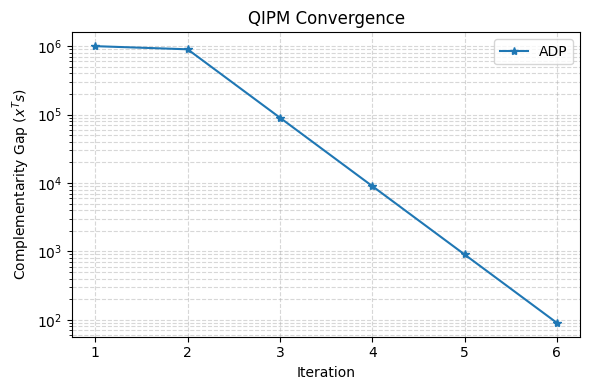

In [13]:
resadp = np.asarray(resadp, dtype=float)
itersadp = np.arange(1, len(resadp) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(itersadp, n*resadp, marker='*', label='ADP') 
plt.xlabel('Iteration')
plt.ylabel(r'Complementarity Gap ($x^T s$)')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

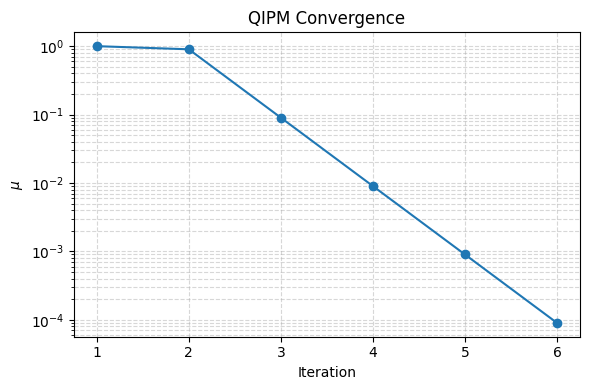

In [14]:
res = np.asarray(resadp, dtype=float)
iters = np.arange(1, len(res) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, res, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$\mu$')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

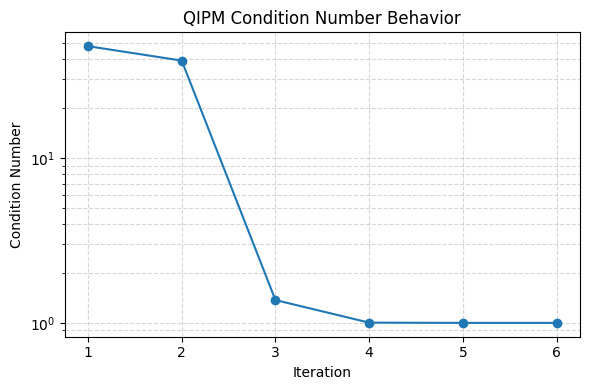

In [15]:
cond = np.asarray(cond, dtype=float)
iters = np.arange(1, len(cond)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, cond, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Condition Number')
plt.title('QIPM Condition Number Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

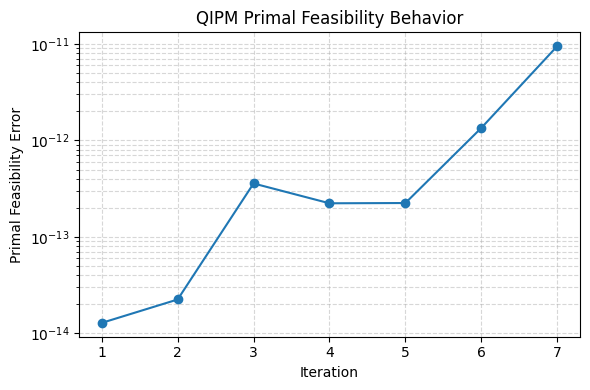

In [16]:
pfeas = np.asarray(pfeas, dtype=float)
iters = np.arange(1, len(pfeas)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, pfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Primal Feasibility Error')
plt.title('QIPM Primal Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

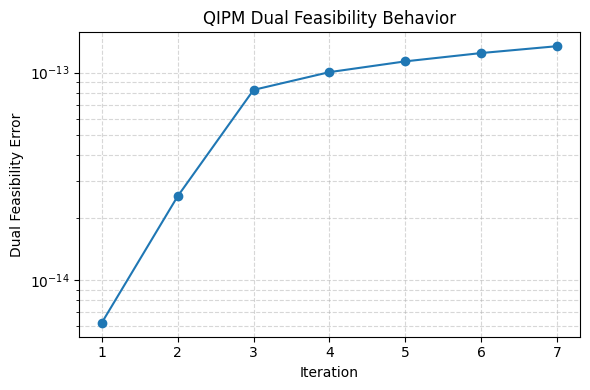

In [17]:
dfeas = np.asarray(dfeas, dtype=float)
iters = np.arange(1, len(dfeas) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, dfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Dual Feasibility Error')
plt.title('QIPM Dual Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Size 32

In [ ]:
m, n = 32, 1000000
parameters = Parameters()
(A, Bidx, b, c, opt_x, opt_y, opt_s, int_x, int_y, int_s) = GenLOwIntOpt(m-1,n-1,m,n-m-1,parameters)
print('Condition Number of Ahat:                 ', format(np.linalg.cond(np.linalg.solve(A[:,Bidx], A)), ".2E"))
print('Initial Solution Complementarity Gap:     ', format(np.dot(int_x,int_s), ".2E"))
print('Initial Solution Primal Feasibility Error:', format(np.linalg.norm(A@int_x-b), ".2E"))
print('Initial Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@int_y)+int_s-c), ".2E"))

print('Optimal Solution Complementarity Gap:     ', format(np.dot(opt_x,opt_s), ".2E"))
print('Optimal Solution Primal Feasibility Error:', format(np.linalg.norm(A@opt_x-b), ".2E"))
print('Optimal Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@opt_y)+opt_s-c), ".2E"))
mu = np.dot(int_x.T, int_s) / n
print('Initial Proximity:                        ', format(np.linalg.norm((int_x*int_s)/mu - np.ones(n)), ".2E"))

In [ ]:
start = time.time()
x,s,y,cond,resadp,pfeas,dfeas,Qcalls,TimeInfo = qipmadaptive(A, Bidx, b, c, 
                                                  int_x, int_y, int_s, 
                                                  n, m, 
                                                  neighborhood = 'Small',
                                                  beta=0.9, 
                                                  gamma= 0.5, # neighborhood parameter
                                                  ir_precision=1e-2, 
                                                  precision=1e-4)
end = time.time()
runtime = end-start

In [ ]:
runtime

In [ ]:
np.linalg.norm(x-opt_x)

In [ ]:
np.linalg.norm(y-opt_y)

In [ ]:
np.linalg.norm(s-opt_s)

In [ ]:
print('Solution Complementarity Gap:                  ', format(np.dot(x,s), ".2E"))
print('Solution Primal Feasibility Error:             ', format(np.linalg.norm(A@x-b), ".2E"))
print('Solution Dual Feasibility Error:               ', format(np.linalg.norm((A.T@y)+s-c), ".2E"))

In [ ]:
print('Total Number of Quantum Calls:                 ', Qcalls)
print('Total Time Spent is System Building:           ', TimeInfo['SB'])
print('Total Time Spent is Circuit Building and Solve:', TimeInfo['SB'])
print('Total Time Spent in Line Search:               ', TimeInfo['LS'])

In [ ]:
resadp = np.asarray(resadp, dtype=float)
iters = np.arange(1, len(resadp) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, n*resadp, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'Complementarity Gap ($x^T s$)')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
res = np.asarray(resadp, dtype=float)
iters = np.arange(1, len(resadp) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, res, marker='o')  # log scale is standard for IPM
plt.xlabel('Iteration')
plt.ylabel(r'$\mu$')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
cond = np.asarray(cond, dtype=float)
iters = np.arange(1, len(cond)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, cond, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Condition Number')
plt.title('QIPM Condition Number Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
pfeas = np.asarray(pfeas, dtype=float)
iters = np.arange(1, len(pfeas)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, pfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Primal Feasibility Error')
plt.title('QIPM Primal Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
dfeas = np.asarray(dfeas, dtype=float)
iters = np.arange(1, len(dfeas) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, dfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Dual Feasibility Error')
plt.title('QIPM Dual Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()